# EDA avanzado para estrategia de joins y feature engineering

Objetivo del notebook:

- entender la granularidad real de cada CSV;
- validar claves primarias y foreign keys antes de hacer joins;
- detectar columnas solapadas entre tablas base y tablas resumen;
- encontrar inconsistencias temporales o acumulados sospechosos;
- dejar una primera tabla limpia para empezar feature engineering sin leakage accidental.

La idea principal: tratar `creative_daily_country_os_stats.csv` como fact table, `creatives.csv`, `campaigns.csv` y `advertisers.csv` como dimensiones, y usar `creative_summary.csv` / `campaign_summary.csv` como agregados o labels, no como dimensiones ciegas.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 160)

if HAS_SEABORN:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")

ROOT = Path.cwd().parent
DATA_DIR = ROOT / "Smadex_Creative_Intelligence_Dataset_FULL"
ASSET_DIR = DATA_DIR / "assets"

assert DATA_DIR.exists(), f"No encuentro el dataset en {DATA_DIR}"
print(f"Root: {ROOT}")
print(f"Dataset: {DATA_DIR}")

Root: /home/wei/projects/hack_UPC_2026
Dataset: /home/wei/projects/hack_UPC_2026/Smadex_Creative_Intelligence_Dataset_FULL


## 1. Carga y mapa de tablas

Parseamos fechas desde el principio para poder comprobar rangos, launches y ventanas temporales. Las tablas resumen se cargan igual que las tablas base, pero más adelante se validan contra la fact table diaria.

In [2]:
FILES = {
    "advertisers": "advertisers.csv",
    "campaigns": "campaigns.csv",
    "creatives": "creatives.csv",
    "daily": "creative_daily_country_os_stats.csv",
    "creative_summary": "creative_summary.csv",
    "campaign_summary": "campaign_summary.csv",
    "dictionary": "data_dictionary.csv",
}

parse_dates = {
    "campaigns": ["start_date", "end_date"],
    "creatives": ["creative_launch_date"],
    "daily": ["date"],
    "creative_summary": ["creative_launch_date"],
    "campaign_summary": ["start_date", "end_date"],
}

dfs = {}
for name, filename in FILES.items():
    path = DATA_DIR / filename
    kwargs = {"parse_dates": parse_dates.get(name, [])}
    dfs[name] = pd.read_csv(path, **kwargs)

advertisers = dfs["advertisers"]
campaigns = dfs["campaigns"]
creatives = dfs["creatives"]
daily = dfs["daily"]
creative_summary = dfs["creative_summary"]
campaign_summary = dfs["campaign_summary"]
dictionary = dfs["dictionary"]

shape_report = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "memory_mb": df.memory_usage(deep=True).sum() / 1_000_000,
            "file": FILES[name],
        }
        for name, df in dfs.items()
    ]
).sort_values("rows", ascending=False)

display(shape_report)

,table,rows,columns,memory_mb,file
3,daily,192315,14,38.663877,creative_daily_country_os_stats.csv
4,creative_summary,1080,59,1.300540,creative_summary.csv
2,creatives,1080,32,1.015020,creatives.csv
5,campaign_summary,180,22,0.110587,campaign_summary.csv
1,campaigns,180,14,0.099067,campaigns.csv
6,dictionary,145,4,0.037261,data_dictionary.csv
0,advertisers,36,4,0.006627,advertisers.csv


In [3]:
# Diccionario de datos navegable por tabla
for table in dictionary["file_name"].drop_duplicates():
    cols = dictionary.loc[dictionary["file_name"].eq(table), ["column_name", "data_type", "description"]]
    print(f"\n{table}: {len(cols)} columnas")
    display(cols.head(12))


advertisers.csv: 4 columnas


,column_name,data_type,description
0,advertiser_id,integer,Unique advertiser identifier
1,advertiser_name,string,Synthetic advertiser name
2,vertical,string,Business vertical
3,hq_region,string,Synthetic headquarters region



campaigns.csv: 14 columnas


,column_name,data_type,description
4,campaign_id,integer,Unique campaign identifier
5,advertiser_id,integer,Foreign key to advertisers.csv
6,advertiser_name,string,Synthetic advertiser name
7,app_name,string,Promoted app or product name
8,vertical,string,Business vertical
9,objective,string,Primary conversion objective
10,primary_theme,string,Main creative angle used in the campaign
11,target_age_segment,string,Primary age segment
12,target_os,string,Target operating system
13,countries,string,Pipe-separated target countries



creatives.csv: 32 columnas


...

,column_name,data_type,description
50,date,object,Observation date
51,campaign_id,int64,Foreign key to campaigns.csv
52,creative_id,int64,Foreign key to creatives.csv
53,country,object,Country of delivery
54,os,object,Operating system
55,days_since_launch,int64,How many days the creative has been active on ...
56,impressions_last_7d,int64,Impressions accumulated by this creative in th...
57,spend_usd,float64,Spend in USD for this creative-country-OS-day ...
58,impressions,int64,Served impressions
59,viewable_impressions,int64,Estimated viewable impressions



creative_summary.csv: 59 columnas


,column_name,data_type,description
64,creative_id,int64,Unique creative identifier
65,campaign_id,int64,Foreign key to campaigns.csv
66,advertiser_name,object,Synthetic advertiser name
67,app_name,object,Promoted app or product name
68,vertical,object,Business vertical
69,format,object,Ad format
70,creative_status,object,"Synthetic label: top_performer, stable, fatigu..."
71,fatigue_day,int64,Approximate day number when performance decay ...
72,total_days_active,int64,NaN
73,total_spend_usd,float64,NaN



campaign_summary.csv: 22 columnas


,column_name,data_type,description
123,campaign_id,int64,NaN
124,total_spend_usd,float64,NaN
125,total_impressions,int64,NaN
126,total_clicks,int64,NaN
127,total_conversions,int64,NaN
128,total_revenue_usd,float64,NaN
129,advertiser_id,int64,NaN
130,advertiser_name,object,NaN
131,app_name,object,NaN
132,vertical,object,NaN


## 2. Perfil general de calidad

Este bloque resume nulos, duplicados completos, columnas constantes y cardinalidades. Sirve para detectar variables que no aportan o claves naturales que parecen tentadoras pero son peligrosas.

In [4]:
def table_profile(df: pd.DataFrame, name: str) -> dict:
    null_cells = int(df.isna().sum().sum())
    constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    return {
        "table": name,
        "rows": len(df),
        "cols": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "null_cells": null_cells,
        "null_pct": null_cells / max(df.size, 1),
        "constant_cols": ", ".join(constant_cols) if constant_cols else "",
    }

profiles = pd.DataFrame(table_profile(df, name) for name, df in dfs.items() if name != "dictionary")
display(profiles)

null_report = []
for name, df in dfs.items():
    if name == "dictionary":
        continue
    miss = df.isna().sum()
    for col, n in miss[miss > 0].items():
        null_report.append({"table": name, "column": col, "nulls": int(n), "null_pct": n / len(df)})

display(pd.DataFrame(null_report).sort_values(["table", "null_pct"], ascending=[True, False]))

,table,rows,cols,duplicate_rows,null_cells,null_pct,constant_cols
0,advertisers,36,4,0,0,0.000000,
1,campaigns,180,14,0,0,0.000000,
2,creatives,1080,32,0,0,0.000000,
3,daily,192315,14,0,0,0.000000,
4,creative_summary,1080,59,0,881,0.013826,
5,campaign_summary,180,22,0,0,0.000000,


,table,column,nulls,null_pct
0,creative_summary,fatigue_day,881,0.815741


In [5]:
# Cardinalidad de posibles claves naturales. Algunas son únicas en una tabla pero no son buenas claves globales.
natural_key_checks = []
for name, df in {
    "advertisers": advertisers,
    "campaigns": campaigns,
    "creatives": creatives,
    "daily": daily,
    "creative_summary": creative_summary,
    "campaign_summary": campaign_summary,
}.items():
    for col in ["advertiser_id", "advertiser_name", "app_name", "campaign_id", "creative_id", "vertical", "country", "os"]:
        if col in df.columns:
            natural_key_checks.append(
                {
                    "table": name,
                    "column": col,
                    "nunique": df[col].nunique(dropna=False),
                    "duplicate_values": int(df.duplicated(col).sum()),
                    "unique_ratio": df[col].nunique(dropna=False) / len(df),
                }
            )

display(pd.DataFrame(natural_key_checks).sort_values(["column", "table"]))

print("app_name no es clave: campañas con nombres de app repetidos")
display(campaigns["app_name"].value_counts().loc[lambda s: s > 1].head(12).rename("campaign_count").to_frame())

,table,column,nunique,duplicate_values,unique_ratio
0,advertisers,advertiser_id,36,0,1.000000
22,campaign_summary,advertiser_id,36,144,0.200000
3,campaigns,advertiser_id,36,144,0.200000
1,advertisers,advertiser_name,36,0,1.000000
23,campaign_summary,advertiser_name,36,144,0.200000
4,campaigns,advertiser_name,36,144,0.200000
17,creative_summary,advertiser_name,36,1044,0.033333
8,creatives,advertiser_name,36,1044,0.033333
24,campaign_summary,app_name,123,57,0.683333
5,campaigns,app_name,123,57,0.683333


app_name no es clave: campañas con nombres de app repetidos


,campaign_count
app_name,
PlateSprint Go,4
PixelForge Legends,3
EarnPath Invest,3
CloudRoute Getaway,3
VaultRun Pay,3
NeonCast Stream,3
QuickFork Kitchen,3
BingeLayer Plus,3
HorizonHop Flights,3


## 3. Claves primarias, granularidad y foreign keys

Validamos primero las claves esperadas por tabla. La fact diaria no es única por `creative_id` ni por `campaign_id`: su grano real es `date x creative_id x country x os`. `campaign_id` dentro de daily es redundante pero útil para auditar.

In [6]:
def key_report(df: pd.DataFrame, table: str, key_cols: list[str]) -> dict:
    duplicated = int(df.duplicated(key_cols).sum())
    return {
        "table": table,
        "key": " + ".join(key_cols),
        "rows": len(df),
        "unique_key_values": df[key_cols].drop_duplicates().shape[0],
        "duplicated_rows_on_key": duplicated,
        "is_unique_key": duplicated == 0,
    }

candidate_keys = {
    "advertisers": ["advertiser_id"],
    "campaigns": ["campaign_id"],
    "creatives": ["creative_id"],
    "daily": ["date", "creative_id", "country", "os"],
    "creative_summary": ["creative_id"],
    "campaign_summary": ["campaign_id"],
}

key_results = pd.DataFrame(
    key_report(dfs[name], name, cols) for name, cols in candidate_keys.items()
)
display(key_results)

,table,key,rows,unique_key_values,duplicated_rows_on_key,is_unique_key
0,advertisers,advertiser_id,36,36,0,True
1,campaigns,campaign_id,180,180,0,True
2,creatives,creative_id,1080,1080,0,True
3,daily,date + creative_id + country + os,192315,192315,0,True
4,creative_summary,creative_id,1080,1080,0,True
5,campaign_summary,campaign_id,180,180,0,True


In [7]:
def fk_coverage(left: pd.DataFrame, right: pd.DataFrame, left_name: str, right_name: str, key_cols: list[str]) -> dict:
    left_keys = left[key_cols].drop_duplicates()
    right_keys = right[key_cols].drop_duplicates()
    merged = left_keys.merge(right_keys, on=key_cols, how="left", indicator=True)
    missing = merged["_merge"].eq("left_only")
    return {
        "relationship": f"{left_name} -> {right_name}",
        "key": " + ".join(key_cols),
        "left_unique_keys": len(left_keys),
        "missing_keys": int(missing.sum()),
        "coverage_pct": 1 - missing.mean(),
    }

fk_checks = pd.DataFrame(
    [
        fk_coverage(campaigns, advertisers, "campaigns", "advertisers", ["advertiser_id"]),
        fk_coverage(campaign_summary, advertisers, "campaign_summary", "advertisers", ["advertiser_id"]),
        fk_coverage(creatives, campaigns, "creatives", "campaigns", ["campaign_id"]),
        fk_coverage(daily, campaigns, "daily", "campaigns", ["campaign_id"]),
        fk_coverage(daily, creatives, "daily", "creatives", ["creative_id"]),
        fk_coverage(creative_summary, creatives, "creative_summary", "creatives", ["creative_id"]),
        fk_coverage(campaign_summary, campaigns, "campaign_summary", "campaigns", ["campaign_id"]),
    ]
)
display(fk_checks)

,relationship,key,left_unique_keys,missing_keys,coverage_pct
0,campaigns -> advertisers,advertiser_id,36,0,1.0
1,campaign_summary -> advertisers,advertiser_id,36,0,1.0
2,creatives -> campaigns,campaign_id,180,0,1.0
3,daily -> campaigns,campaign_id,180,0,1.0
4,daily -> creatives,creative_id,1080,0,1.0
5,creative_summary -> creatives,creative_id,1080,0,1.0
6,campaign_summary -> campaigns,campaign_id,180,0,1.0


In [8]:
# campaign_id de daily debe coincidir con el campaign_id oficial del creative_id.
creative_campaign_map = creatives[["creative_id", "campaign_id"]].rename(columns={"campaign_id": "campaign_id_from_creatives"})
daily_campaign_check = (
    daily[["creative_id", "campaign_id"]]
    .drop_duplicates()
    .merge(creative_campaign_map, on="creative_id", how="left", validate="m:1")
)
daily_campaign_check["campaign_mismatch"] = daily_campaign_check["campaign_id"].ne(daily_campaign_check["campaign_id_from_creatives"])

print(f"Pares daily creative_id/campaign_id distintos: {len(daily_campaign_check):,}")
print(f"Mismatches contra creatives.csv: {daily_campaign_check['campaign_mismatch'].sum():,}")
display(daily_campaign_check.loc[daily_campaign_check["campaign_mismatch"]].head(20))

Pares daily creative_id/campaign_id distintos: 1,080
Mismatches contra creatives.csv: 0


,creative_id,campaign_id,campaign_id_from_creatives,campaign_mismatch


## 4. Auditoría de columnas solapadas

Hay datos repetidos en varias tablas (`advertiser_name`, `app_name`, `vertical`, metadata creativa, métricas agregadas). Esta sección diferencia solape benigno de inconsistencia real.

Regla práctica para joins: si una columna existe tanto en tabla base como en summary, no la arrastres dos veces. Usa una fuente canónica y valida que la otra coincide.

In [9]:
def compare_overlapping_columns(
    left: pd.DataFrame,
    right: pd.DataFrame,
    left_name: str,
    right_name: str,
    key_cols: list[str],
    numeric_atol: float = 1e-8,
    numeric_rtol: float = 1e-8,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    common = [c for c in left.columns.intersection(right.columns) if c not in key_cols]
    merged = left[key_cols + common].merge(
        right[key_cols + common],
        on=key_cols,
        how="outer",
        suffixes=("__left", "__right"),
        indicator=True,
        validate="1:1",
    )

    rows = []
    examples = []
    for col in common:
        lcol, rcol = f"{col}__left", f"{col}__right"
        l = merged[lcol]
        r = merged[rcol]
        if pd.api.types.is_numeric_dtype(l) and pd.api.types.is_numeric_dtype(r):
            mismatch = ~np.isclose(l.astype(float), r.astype(float), atol=numeric_atol, rtol=numeric_rtol, equal_nan=True)
        else:
            mismatch = l.fillna("__NA__").astype(str).ne(r.fillna("__NA__").astype(str))
        n = int(mismatch.sum())
        rows.append(
            {
                "pair": f"{left_name} vs {right_name}",
                "column": col,
                "mismatch_rows": n,
                "mismatch_pct": n / len(merged) if len(merged) else 0,
                "left_dtype": str(l.dtype),
                "right_dtype": str(r.dtype),
            }
        )
        if n:
            sample_cols = key_cols + [lcol, rcol]
            ex = merged.loc[mismatch, sample_cols].head(5).copy()
            ex.insert(0, "column", col)
            examples.append(ex)

    report = pd.DataFrame(rows).sort_values(["mismatch_rows", "column"], ascending=[False, True])
    example_df = pd.concat(examples, ignore_index=True) if examples else pd.DataFrame()
    return report, example_df

campaign_overlap, campaign_overlap_examples = compare_overlapping_columns(
    campaigns, campaign_summary, "campaigns", "campaign_summary", ["campaign_id"]
)
creative_overlap, creative_overlap_examples = compare_overlapping_columns(
    creatives, creative_summary, "creatives", "creative_summary", ["creative_id"]
)

display(pd.concat([campaign_overlap, creative_overlap], ignore_index=True))

print("Ejemplos de inconsistencias en columnas solapadas, si existen:")
display(pd.concat([campaign_overlap_examples, creative_overlap_examples], ignore_index=True))

,pair,column,mismatch_rows,mismatch_pct,left_dtype,right_dtype
0,campaigns vs campaign_summary,advertiser_id,0,0.0,int64,int64
1,campaigns vs campaign_summary,advertiser_name,0,0.0,str,str
2,campaigns vs campaign_summary,app_name,0,0.0,str,str
3,campaigns vs campaign_summary,countries,0,0.0,str,str
4,campaigns vs campaign_summary,daily_budget_usd,0,0.0,int64,int64
5,campaigns vs campaign_summary,end_date,0,0.0,datetime64[us],datetime64[us]
6,campaigns vs campaign_summary,kpi_goal,0,0.0,str,str
7,campaigns vs campaign_summary,objective,0,0.0,str,str
8,campaigns vs campaign_summary,primary_theme,0,0.0,str,str
9,campaigns vs campaign_summary,start_date,0,0.0,datetime64[us],datetime64[us]


Ejemplos de inconsistencias en columnas solapadas, si existen:


""


## 5. ¿Los summaries coinciden con la fact table?

Las tablas `creative_summary` y `campaign_summary` son agregados precomputados. Antes de usarlas como labels o como atajos de demo, comprobamos que sus totales salen de `daily`.

In [10]:
def safe_div(num, den):
    return np.where(den == 0, np.nan, num / den)

creative_from_daily = (
    daily.groupby(["creative_id", "campaign_id"], as_index=False)
    .agg(
        calc_total_days_active=("date", "nunique"),
        calc_total_spend_usd=("spend_usd", "sum"),
        calc_total_impressions=("impressions", "sum"),
        calc_total_clicks=("clicks", "sum"),
        calc_total_conversions=("conversions", "sum"),
        calc_total_revenue_usd=("revenue_usd", "sum"),
        first_date=("date", "min"),
        last_date=("date", "max"),
        fact_rows=("date", "size"),
    )
)
creative_from_daily["calc_overall_ctr"] = safe_div(creative_from_daily["calc_total_clicks"], creative_from_daily["calc_total_impressions"])
creative_from_daily["calc_overall_cvr"] = safe_div(creative_from_daily["calc_total_conversions"], creative_from_daily["calc_total_clicks"])
creative_from_daily["calc_overall_ipm"] = safe_div(creative_from_daily["calc_total_conversions"] * 1000, creative_from_daily["calc_total_impressions"])
creative_from_daily["calc_overall_roas"] = safe_div(creative_from_daily["calc_total_revenue_usd"], creative_from_daily["calc_total_spend_usd"])

creative_summary_check = creative_summary.merge(
    creative_from_daily,
    on=["creative_id", "campaign_id"],
    how="outer",
    indicator=True,
    validate="1:1",
)

def metric_comparison(check_df, metric_pairs, id_cols):
    rows = []
    examples = []
    for original, calc, tol in metric_pairs:
        diff = (check_df[original] - check_df[calc]).abs()
        bad = diff.gt(tol) | check_df[original].isna().ne(check_df[calc].isna())
        rows.append(
            {
                "metric": original,
                "calc_metric": calc,
                "bad_rows": int(bad.sum()),
                "max_abs_diff": float(diff.max(skipna=True)),
                "mean_abs_diff": float(diff.mean(skipna=True)),
                "tolerance": tol,
            }
        )
        if bad.any():
            sample = check_df.loc[bad, id_cols + [original, calc]].head(5).copy()
            sample.insert(0, "metric", original)
            examples.append(sample)
    return pd.DataFrame(rows), pd.concat(examples, ignore_index=True) if examples else pd.DataFrame()

creative_metric_pairs = [
    ("total_days_active", "calc_total_days_active", 0),
    ("total_spend_usd", "calc_total_spend_usd", 0.02),
    ("total_impressions", "calc_total_impressions", 0),
    ("total_clicks", "calc_total_clicks", 0),
    ("total_conversions", "calc_total_conversions", 0),
    ("total_revenue_usd", "calc_total_revenue_usd", 0.02),
    ("overall_ctr", "calc_overall_ctr", 1e-10),
    ("overall_cvr", "calc_overall_cvr", 1e-10),
    ("overall_ipm", "calc_overall_ipm", 1e-10),
    ("overall_roas", "calc_overall_roas", 1e-10),
]
creative_metric_report, creative_metric_examples = metric_comparison(
    creative_summary_check, creative_metric_pairs, ["creative_id", "campaign_id"]
)

print("Cobertura creative_summary vs daily aggregate:")
display(creative_summary_check["_merge"].value_counts().rename("rows").to_frame())
display(creative_metric_report)
display(creative_metric_examples)

Cobertura creative_summary vs daily aggregate:


,rows
_merge,
both,1080
left_only,0
right_only,0


,metric,calc_metric,bad_rows,max_abs_diff,mean_abs_diff,tolerance
0,total_days_active,calc_total_days_active,0,0.000000e+00,0.000000e+00,0.000000e+00
1,total_spend_usd,calc_total_spend_usd,0,7.275958e-12,1.263187e-13,2.000000e-02
2,total_impressions,calc_total_impressions,0,0.000000e+00,0.000000e+00,0.000000e+00
3,total_clicks,calc_total_clicks,0,0.000000e+00,0.000000e+00,0.000000e+00
4,total_conversions,calc_total_conversions,0,0.000000e+00,0.000000e+00,0.000000e+00
5,total_revenue_usd,calc_total_revenue_usd,0,5.820766e-11,7.511753e-13,2.000000e-02
6,overall_ctr,calc_overall_ctr,0,9.974660e-17,4.759768e-17,1.000000e-10
7,overall_cvr,calc_overall_cvr,0,9.714451e-17,4.351586e-17,1.000000e-10
8,overall_ipm,calc_overall_ipm,0,8.881784e-16,4.291834e-17,1.000000e-10
9,overall_roas,calc_overall_roas,0,5.329071e-15,1.185266e-16,1.000000e-10


""


In [11]:
campaign_from_daily = (
    daily.groupby("campaign_id", as_index=False)
    .agg(
        calc_total_spend_usd=("spend_usd", "sum"),
        calc_total_impressions=("impressions", "sum"),
        calc_total_clicks=("clicks", "sum"),
        calc_total_conversions=("conversions", "sum"),
        calc_total_revenue_usd=("revenue_usd", "sum"),
    )
)
campaign_from_daily["calc_overall_ctr"] = safe_div(campaign_from_daily["calc_total_clicks"], campaign_from_daily["calc_total_impressions"])
campaign_from_daily["calc_overall_cvr"] = safe_div(campaign_from_daily["calc_total_conversions"], campaign_from_daily["calc_total_clicks"])
campaign_from_daily["calc_overall_roas"] = safe_div(campaign_from_daily["calc_total_revenue_usd"], campaign_from_daily["calc_total_spend_usd"])

campaign_summary_check = campaign_summary.merge(
    campaign_from_daily,
    on="campaign_id",
    how="outer",
    indicator=True,
    validate="1:1",
)

campaign_metric_pairs = [
    ("total_spend_usd", "calc_total_spend_usd", 0.02),
    ("total_impressions", "calc_total_impressions", 0),
    ("total_clicks", "calc_total_clicks", 0),
    ("total_conversions", "calc_total_conversions", 0),
    ("total_revenue_usd", "calc_total_revenue_usd", 0.02),
    ("overall_ctr", "calc_overall_ctr", 1e-10),
    ("overall_cvr", "calc_overall_cvr", 1e-10),
    ("overall_roas", "calc_overall_roas", 1e-10),
]
campaign_metric_report, campaign_metric_examples = metric_comparison(
    campaign_summary_check, campaign_metric_pairs, ["campaign_id"]
)

print("Cobertura campaign_summary vs daily aggregate:")
display(campaign_summary_check["_merge"].value_counts().rename("rows").to_frame())
display(campaign_metric_report)
display(campaign_metric_examples)

Cobertura campaign_summary vs daily aggregate:


,rows
_merge,
both,180
left_only,0
right_only,0


,metric,calc_metric,bad_rows,max_abs_diff,mean_abs_diff,tolerance
0,total_spend_usd,calc_total_spend_usd,0,2.910383e-11,1.616879e-13,2.000000e-02
1,total_impressions,calc_total_impressions,0,0.000000e+00,0.000000e+00,0.000000e+00
2,total_clicks,calc_total_clicks,0,0.000000e+00,0.000000e+00,0.000000e+00
3,total_conversions,calc_total_conversions,0,0.000000e+00,0.000000e+00,0.000000e+00
4,total_revenue_usd,calc_total_revenue_usd,0,2.328306e-10,1.293504e-12,2.000000e-02
5,overall_ctr,calc_overall_ctr,0,9.887924e-17,5.315964e-17,1.000000e-10
6,overall_cvr,calc_overall_cvr,0,9.714451e-17,4.552685e-17,1.000000e-10
7,overall_roas,calc_overall_roas,0,1.776357e-15,8.079956e-17,1.000000e-10


""


## 6. Integridad temporal, targeting y grano de daily

Aquí comprobamos que las filas diarias caen dentro de las fechas de campaña, que `days_since_launch` coincide con `date - creative_launch_date`, y que los países/OS observados respetan el targeting de campaña.

In [12]:
# Rango temporal y granularidad.
rows_per_creative_day = daily.groupby(["creative_id", "date"]).size().rename("rows_per_creative_date")
rows_per_campaign_day = daily.groupby(["campaign_id", "date"]).size().rename("rows_per_campaign_date")

display(
    pd.DataFrame(
        {
            "daily_min_date": [daily["date"].min()],
            "daily_max_date": [daily["date"].max()],
            "creative_days": [daily[["creative_id", "date"]].drop_duplicates().shape[0]],
            "daily_rows": [len(daily)],
            "avg_country_os_slices_per_creative_day": [rows_per_creative_day.mean()],
            "max_country_os_slices_per_creative_day": [rows_per_creative_day.max()],
        }
    )
)

display(rows_per_creative_day.describe().to_frame().T)
display(rows_per_creative_day.value_counts().sort_index().rename("creative_date_count").to_frame())

,daily_min_date,daily_max_date,creative_days,daily_rows,avg_country_os_slices_per_creative_day,max_country_os_slices_per_creative_day
0,2026-01-01,2026-03-16,52349,192315,3.673709,8


,count,mean,std,min,25%,50%,75%,max
rows_per_creative_date,52349.0,3.673709,1.718274,2.0,2.0,3.0,4.0,8.0


,creative_date_count
rows_per_creative_date,
2,15660
3,13590
4,12643
5,191
6,6711
8,3554


In [13]:
# days_since_launch y fechas de campaña.
temporal = daily.merge(
    creatives[["creative_id", "creative_launch_date"]], on="creative_id", how="left", validate="m:1"
).merge(
    campaigns[["campaign_id", "start_date", "end_date"]], on="campaign_id", how="left", validate="m:1"
)
temporal["calc_days_since_launch"] = (temporal["date"] - temporal["creative_launch_date"]).dt.days

temporal_report = pd.DataFrame(
    [
        {"check": "days_since_launch == date - creative_launch_date", "bad_rows": int(temporal["days_since_launch"].ne(temporal["calc_days_since_launch"]).sum())},
        {"check": "date >= creative_launch_date", "bad_rows": int(temporal["date"].lt(temporal["creative_launch_date"]).sum())},
        {"check": "date >= campaign start_date", "bad_rows": int(temporal["date"].lt(temporal["start_date"]).sum())},
        {"check": "date <= campaign end_date", "bad_rows": int(temporal["date"].gt(temporal["end_date"]).sum())},
    ]
)
display(temporal_report)

,check,bad_rows
0,days_since_launch == date - creative_launch_date,0
1,date >= creative_launch_date,0
2,date >= campaign start_date,0
3,date <= campaign end_date,0


In [14]:
# Targeting country/OS.
campaign_country_map = campaigns.set_index("campaign_id")["countries"].str.split("|").to_dict()
campaign_os_map = campaigns.set_index("campaign_id")["target_os"].to_dict()

target_check = daily[["campaign_id", "country", "os"]].drop_duplicates().copy()
target_check["country_in_campaign_targets"] = target_check.apply(
    lambda r: r["country"] in campaign_country_map.get(r["campaign_id"], []), axis=1
)
target_check["os_in_campaign_targets"] = target_check.apply(
    lambda r: campaign_os_map.get(r["campaign_id"]) in ["Both", r["os"]], axis=1
)

display(
    pd.DataFrame(
        [
            {"check": "country in campaigns.countries", "bad_distinct_campaign_country_os": int((~target_check["country_in_campaign_targets"]).sum())},
            {"check": "os compatible with campaigns.target_os", "bad_distinct_campaign_country_os": int((~target_check["os_in_campaign_targets"]).sum())},
        ]
    )
)

display(target_check.loc[~target_check["country_in_campaign_targets"] | ~target_check["os_in_campaign_targets"]].head(20))

,check,bad_distinct_campaign_country_os
0,country in campaigns.countries,0
1,os compatible with campaigns.target_os,0


,campaign_id,country,os,country_in_campaign_targets,os_in_campaign_targets


## 7. Variable sospechosa: `impressions_last_7d`

El nombre sugiere ventana temporal de 7 días, pero conviene comprobarlo. En este dataset coincide exactamente con la suma de las 7 filas anteriores por `creative_id` en el orden del CSV, no con los 7 días calendario anteriores. Como daily tiene varias filas por día (`country x os`), esta variable es dependiente del orden de filas y no debería usarse tal cual para modelos temporales.

In [15]:
# Check 1: rolling de 7 filas anteriores en el orden del CSV.
daily_file_order = daily.copy()
daily_file_order["calc_prev_7_rows_impressions"] = (
    daily_file_order.groupby("creative_id")["impressions"]
    .transform(lambda s: s.shift(1).rolling(7, min_periods=1).sum())
    .fillna(0)
    .astype("int64")
)
row_order_matches = daily_file_order["impressions_last_7d"].eq(daily_file_order["calc_prev_7_rows_impressions"])

# Check 2: rolling limpio de 7 días calendario agregando primero por creative_id-date.
creative_day = (
    daily.groupby(["creative_id", "campaign_id", "date", "days_since_launch"], as_index=False)
    .agg(
        spend_usd=("spend_usd", "sum"),
        impressions=("impressions", "sum"),
        viewable_impressions=("viewable_impressions", "sum"),
        clicks=("clicks", "sum"),
        conversions=("conversions", "sum"),
        revenue_usd=("revenue_usd", "sum"),
        video_completions=("video_completions", "sum"),
        country_os_slices=("country", "size"),
    )
    .sort_values(["creative_id", "date"])
)
creative_day["calc_prev_7_calendar_days_impressions"] = (
    creative_day.groupby("creative_id")["impressions"]
    .transform(lambda s: s.shift(1).rolling(7, min_periods=1).sum())
    .fillna(0)
    .astype("int64")
)

# Comparamos los min/max de impressions_last_7d dentro del mismo creative-date contra la ventana calendario.
daily_imp7_by_day = (
    daily.groupby(["creative_id", "date"], as_index=False)
    .agg(imp7_min=("impressions_last_7d", "min"), imp7_max=("impressions_last_7d", "max"), imp7_nunique=("impressions_last_7d", "nunique"))
)
imp7_calendar_check = daily_imp7_by_day.merge(
    creative_day[["creative_id", "date", "calc_prev_7_calendar_days_impressions"]], on=["creative_id", "date"], how="left", validate="1:1"
)

impressions_last_7d_report = pd.DataFrame(
    [
        {
            "hypothesis": "impressions_last_7d == suma de las 7 filas anteriores por creative_id",
            "matching_rows": int(row_order_matches.sum()),
            "total_rows": len(daily),
            "match_pct": row_order_matches.mean(),
        },
        {
            "hypothesis": "mismo valor para todas las slices del mismo creative-date",
            "matching_rows": int(imp7_calendar_check["imp7_nunique"].eq(1).sum()),
            "total_rows": len(imp7_calendar_check),
            "match_pct": imp7_calendar_check["imp7_nunique"].eq(1).mean(),
        },
        {
            "hypothesis": "imp7_min == rolling 7 días calendario previos",
            "matching_rows": int(imp7_calendar_check["imp7_min"].eq(imp7_calendar_check["calc_prev_7_calendar_days_impressions"]).sum()),
            "total_rows": len(imp7_calendar_check),
            "match_pct": imp7_calendar_check["imp7_min"].eq(imp7_calendar_check["calc_prev_7_calendar_days_impressions"]).mean(),
        },
    ]
)

display(impressions_last_7d_report)

sample_creative = daily["creative_id"].iloc[0]
display(
    daily_file_order.loc[daily_file_order["creative_id"].eq(sample_creative), [
        "date", "country", "os", "impressions", "impressions_last_7d", "calc_prev_7_rows_impressions"
    ]].head(18)
)

,hypothesis,matching_rows,total_rows,match_pct
0,impressions_last_7d == suma de las 7 filas ant...,192315,192315,1.00000
1,mismo valor para todas las slices del mismo cr...,0,52349,0.00000
2,imp7_min == rolling 7 días calendario previos,2919,52349,0.05576


,date,country,os,impressions,impressions_last_7d,calc_prev_7_rows_impressions
0,2026-01-19,CA,Android,317764,0,0
1,2026-01-19,CA,iOS,233737,317764,317764
2,2026-01-19,US,Android,33591,551501,551501
3,2026-01-19,US,iOS,35524,585092,585092
4,2026-01-19,ES,Android,62072,620616,620616
5,2026-01-19,ES,iOS,65410,682688,682688
6,2026-01-19,JP,Android,103480,748098,748098
7,2026-01-19,JP,iOS,88882,851578,851578
8,2026-01-20,CA,Android,161673,622696,622696
10,2026-01-20,CA,iOS,101989,550632,550632


In [16]:
# Construimos ventanas temporales limpias a nivel creative_id-date.
for window in [3, 7, 14]:
    creative_day[f"impressions_prev_{window}d"] = (
        creative_day.groupby("creative_id")["impressions"]
        .transform(lambda s, w=window: s.shift(1).rolling(w, min_periods=1).sum())
        .fillna(0)
    )
    creative_day[f"clicks_prev_{window}d"] = (
        creative_day.groupby("creative_id")["clicks"]
        .transform(lambda s, w=window: s.shift(1).rolling(w, min_periods=1).sum())
        .fillna(0)
    )
    creative_day[f"conversions_prev_{window}d"] = (
        creative_day.groupby("creative_id")["conversions"]
        .transform(lambda s, w=window: s.shift(1).rolling(w, min_periods=1).sum())
        .fillna(0)
    )
    creative_day[f"ctr_prev_{window}d"] = safe_div(creative_day[f"clicks_prev_{window}d"], creative_day[f"impressions_prev_{window}d"])
    creative_day[f"cvr_prev_{window}d"] = safe_div(creative_day[f"conversions_prev_{window}d"], creative_day[f"clicks_prev_{window}d"])

creative_day["ctr"] = safe_div(creative_day["clicks"], creative_day["impressions"])
creative_day["cvr"] = safe_div(creative_day["conversions"], creative_day["clicks"])
creative_day["ipm"] = safe_div(creative_day["conversions"] * 1000, creative_day["impressions"])
creative_day["roas"] = safe_div(creative_day["revenue_usd"], creative_day["spend_usd"])

display(creative_day.head(12))

,creative_id,campaign_id,date,days_since_launch,spend_usd,impressions,viewable_impressions,clicks,conversions,revenue_usd,video_completions,country_os_slices,calc_prev_7_calendar_days_impressions,impressions_prev_3d,clicks_prev_3d,conversions_prev_3d,ctr_prev_3d,cvr_prev_3d,impressions_prev_7d,clicks_prev_7d,conversions_prev_7d,ctr_prev_7d,cvr_prev_7d,impressions_prev_14d,clicks_prev_14d,conversions_prev_14d,ctr_prev_14d,cvr_prev_14d,ctr,cvr,ipm,roas
0,500000,20000,2026-01-19,0,5917.42,940460,769746,10626,2156,11713.79,0,8,0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.011299,0.202899,2.292495,1.979543
1,500000,20000,2026-01-20,1,2669.38,450862,376573,4302,905,4990.81,0,8,940460,940460.0,10626.0,2156.0,0.011299,0.202899,940460.0,10626.0,2156.0,0.011299,0.202899,940460.0,10626.0,2156.0,0.011299,0.202899,0.009542,0.210367,2.007266,1.869651
2,500000,20000,2026-01-21,2,2804.97,455904,381052,3924,721,4024.43,0,8,1391322,1391322.0,14928.0,3061.0,0.010729,0.205051,1391322.0,14928.0,3061.0,0.010729,0.205051,1391322.0,14928.0,3061.0,0.010729,0.205051,0.008607,0.183741,1.581473,1.434750
3,500000,20000,2026-01-22,3,2202.00,347661,283529,2831,550,2832.93,0,8,1847226,1847226.0,18852.0,3782.0,0.010206,0.200615,1847226.0,18852.0,3782.0,0.010206,0.200615,1847226.0,18852.0,3782.0,0.010206,0.200615,0.008143,0.194278,1.582001,1.286526
4,500000,20000,2026-01-23,4,2332.58,380006,303292,2475,467,2374.40,0,8,2194887,1254427.0,11057.0,2176.0,0.008814,0.196798,2194887.0,21683.0,4332.0,0.009879,0.199788,2194887.0,21683.0,4332.0,0.009879,0.199788,0.006513,0.188687,1.228928,1.017929
5,500000,20000,2026-01-24,5,2446.50,416192,332945,2423,492,2726.76,0,8,2574893,1183571.0,9230.0,1738.0,0.007798,0.188299,2574893.0,24158.0,4799.0,0.009382,0.198651,2574893.0,24158.0,4799.0,0.009382,0.198651,0.005822,0.203054,1.182147,1.114555
6,500000,20000,2026-01-25,6,2037.02,323169,265251,1487,269,1608.16,0,8,2991085,1143859.0,7729.0,1509.0,0.006757,0.195239,2991085.0,26581.0,5291.0,0.008887,0.199052,2991085.0,26581.0,5291.0,0.008887,0.199052,0.004601,0.180901,0.832382,0.789467
7,500000,20000,2026-01-26,7,1980.32,314991,252560,1443,289,1686.24,0,8,3314254,1119367.0,6385.0,1228.0,0.005704,0.192326,3314254.0,28068.0,5560.0,0.008469,0.198090,3314254.0,28068.0,5560.0,0.008469,0.198090,0.004581,0.200277,0.917487,0.851499
8,500000,20000,2026-01-27,8,1663.47,259893,217679,932,188,1039.80,0,8,2688785,1054352.0,5353.0,1050.0,0.005077,0.196152,2688785.0,18885.0,3693.0,0.007024,0.195552,3629245.0,29511.0,5849.0,0.008131,0.198197,0.003586,0.201717,0.723375,0.625079
9,500000,20000,2026-01-28,9,1156.98,196164,155663,644,118,645.32,0,8,2497816,898053.0,3862.0,746.0,0.004300,0.193164,2497816.0,15515.0,2976.0,0.006211,0.191814,3889138.0,30443.0,6037.0,0.007828,0.198305,0.003283,0.183230,0.601537,0.557762


## 8. Estrategia de join recomendada

Conclusión práctica:

- `advertiser_id`, `campaign_id` y `creative_id` son las claves canónicas.
- Para enriquecer daily con metadata creativa, une por `creative_id` y valida que `campaign_id` coincide.
- Para metadata de campaña, une `creatives -> campaigns` por `campaign_id`; luego añade `advertisers` por `advertiser_id` solo para `hq_region` u otros campos que no estén ya en campaigns.
- No uses `app_name`, `advertiser_name`, `headline`, `theme` o `asset_file` como claves de join aunque parezcan informativas.
- Trata `creative_summary` como tabla de labels/agregados, no como dimensión base, porque duplica muchas columnas de `creatives` y agrega información de todo el periodo.

In [17]:
join_decisions = pd.DataFrame(
    [
        {
            "join": "campaigns <- advertisers",
            "key": "advertiser_id",
            "validate": "m:1",
            "canonical_source": "campaigns para advertiser_name/vertical; advertisers para hq_region",
            "risk": "bajo",
        },
        {
            "join": "creatives <- campaigns",
            "key": "campaign_id",
            "validate": "m:1",
            "canonical_source": "creatives para metadata creativa; campaigns para targeting/setup",
            "risk": "bajo",
        },
        {
            "join": "daily <- creatives",
            "key": "creative_id",
            "validate": "m:1",
            "canonical_source": "daily para métricas temporales; creatives para atributos del asset",
            "risk": "bajo si se audita campaign_id",
        },
        {
            "join": "creative_summary <- creatives",
            "key": "creative_id",
            "validate": "1:1",
            "canonical_source": "summary solo para labels/totales; creatives para metadata",
            "risk": "leakage si se usa para features pre-evento",
        },
        {
            "join": "campaign_summary <- campaigns",
            "key": "campaign_id",
            "validate": "1:1",
            "canonical_source": "summary solo para KPIs agregados de campaña",
            "risk": "duplica columnas de campaigns",
        },
    ]
)
display(join_decisions)

,join,key,validate,canonical_source,risk
0,campaigns <- advertisers,advertiser_id,m:1,campaigns para advertiser_name/vertical; adver...,bajo
1,creatives <- campaigns,campaign_id,m:1,creatives para metadata creativa; campaigns pa...,bajo
2,daily <- creatives,creative_id,m:1,daily para métricas temporales; creatives para...,bajo si se audita campaign_id
3,creative_summary <- creatives,creative_id,1:1,summary solo para labels/totales; creatives pa...,leakage si se usa para features pre-evento
4,campaign_summary <- campaigns,campaign_id,1:1,summary solo para KPIs agregados de campaña,duplica columnas de campaigns


In [18]:
# Dimensiones limpias, evitando columnas duplicadas innecesarias.
advertiser_dim = advertisers.copy()

campaign_context_cols = [
    "campaign_id", "advertiser_id", "objective", "primary_theme", "target_age_segment",
    "target_os", "countries", "start_date", "end_date", "daily_budget_usd", "kpi_goal",
]
campaign_dim = campaigns[campaign_context_cols].merge(
    advertiser_dim[["advertiser_id", "hq_region"]],
    on="advertiser_id",
    how="left",
    validate="m:1",
)

creative_context_cols = [
    "creative_id", "campaign_id", "advertiser_name", "app_name", "vertical", "format",
    "width", "height", "language", "creative_launch_date", "theme", "hook_type", "cta_text",
    "headline", "subhead", "dominant_color", "emotional_tone", "duration_sec", "text_density",
    "copy_length_chars", "readability_score", "brand_visibility_score", "clutter_score",
    "novelty_score", "motion_score", "faces_count", "product_count", "has_price",
    "has_discount_badge", "has_gameplay", "has_ugc_style", "asset_file",
]
creative_dim = creatives[creative_context_cols].merge(
    campaign_dim,
    on="campaign_id",
    how="left",
    validate="m:1",
)

# Fact enriched: usamos creative_id para traer metadata y auditamos la campaign_id redundante.
daily_enriched = daily.merge(
    creative_dim.drop(columns=["campaign_id"]),
    on="creative_id",
    how="left",
    validate="m:1",
)
# Reinsertamos campaign_id oficial del creative para comprobar contra daily.
daily_enriched = daily_enriched.merge(
    creatives[["creative_id", "campaign_id"]].rename(columns={"campaign_id": "campaign_id_from_creatives"}),
    on="creative_id",
    how="left",
    validate="m:1",
)
assert daily_enriched["campaign_id"].eq(daily_enriched["campaign_id_from_creatives"]).all()
daily_enriched = daily_enriched.drop(columns=["campaign_id_from_creatives"])

print("campaign_dim", campaign_dim.shape)
print("creative_dim", creative_dim.shape)
print("daily_enriched", daily_enriched.shape)
display(daily_enriched.head())

campaign_dim (180, 12)
creative_dim (1080, 43)
daily_enriched (192315, 55)


,date,campaign_id,creative_id,country,os,days_since_launch,impressions_last_7d,spend_usd,impressions,viewable_impressions,clicks,conversions,revenue_usd,video_completions,advertiser_name,app_name,vertical,format,width,height,language,creative_launch_date,theme,hook_type,cta_text,headline,subhead,dominant_color,emotional_tone,duration_sec,text_density,copy_length_chars,readability_score,brand_visibility_score,clutter_score,novelty_score,motion_score,faces_count,product_count,has_price,has_discount_badge,has_gameplay,has_ugc_style,asset_file,advertiser_id,objective,primary_theme,target_age_segment,target_os,countries,start_date,end_date,daily_budget_usd,kpi_goal,hq_region
0,2026-01-19,20000,500000,CA,Android,0,0,1975.84,317764,271361,4385,904,5034.81,0,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,family,power-up,Order now,Level up today,Play with friends tonight,purple,premium,5,0.419,37,0.75,0.733,0.466,0.366,0.823,0,2,0,0,1,0,assets/creative_500000.png,1000,install,fantasy,45-54,Both,CA|US|ES|JP,2026-01-19,2026-04-02,5386,CPA,LATAM
1,2026-01-19,20000,500000,CA,iOS,0,317764,1547.39,233737,185367,2413,467,2125.05,0,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,family,power-up,Order now,Level up today,Play with friends tonight,purple,premium,5,0.419,37,0.75,0.733,0.466,0.366,0.823,0,2,0,0,1,0,assets/creative_500000.png,1000,install,fantasy,45-54,Both,CA|US|ES|JP,2026-01-19,2026-04-02,5386,CPA,LATAM
2,2026-01-19,20000,500000,US,Android,0,551501,233.67,33591,26121,308,51,244.58,0,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,family,power-up,Order now,Level up today,Play with friends tonight,purple,premium,5,0.419,37,0.75,0.733,0.466,0.366,0.823,0,2,0,0,1,0,assets/creative_500000.png,1000,install,fantasy,45-54,Both,CA|US|ES|JP,2026-01-19,2026-04-02,5386,CPA,LATAM
3,2026-01-19,20000,500000,US,iOS,0,585092,256.34,35524,26405,388,78,367.42,0,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,family,power-up,Order now,Level up today,Play with friends tonight,purple,premium,5,0.419,37,0.75,0.733,0.466,0.366,0.823,0,2,0,0,1,0,assets/creative_500000.png,1000,install,fantasy,45-54,Both,CA|US|ES|JP,2026-01-19,2026-04-02,5386,CPA,LATAM
4,2026-01-19,20000,500000,ES,Android,0,620616,265.09,62072,48430,578,104,681.18,0,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,family,power-up,Order now,Level up today,Play with friends tonight,purple,premium,5,0.419,37,0.75,0.733,0.466,0.366,0.823,0,2,0,0,1,0,assets/creative_500000.png,1000,install,fantasy,45-54,Both,CA|US|ES|JP,2026-01-19,2026-04-02,5386,CPA,LATAM


## 9. Tabla base para feature engineering

Creamos una primera tabla a nivel `creative_id`. La parte de features usa metadata creativa/campaña y métricas tempranas calculadas desde daily. La parte de targets usa `creative_summary` (`creative_status`, `perf_score`, etc.) y queda separada conceptualmente para evitar leakage.

In [19]:
def aggregate_window(day_df: pd.DataFrame, max_day_inclusive: int, prefix: str) -> pd.DataFrame:
    w = day_df.loc[day_df["days_since_launch"].le(max_day_inclusive)].copy()
    out = (
        w.groupby("creative_id", as_index=False)
        .agg(
            **{
                f"{prefix}_days_observed": ("date", "nunique"),
                f"{prefix}_spend_usd": ("spend_usd", "sum"),
                f"{prefix}_impressions": ("impressions", "sum"),
                f"{prefix}_viewable_impressions": ("viewable_impressions", "sum"),
                f"{prefix}_clicks": ("clicks", "sum"),
                f"{prefix}_conversions": ("conversions", "sum"),
                f"{prefix}_revenue_usd": ("revenue_usd", "sum"),
                f"{prefix}_avg_country_os_slices": ("country_os_slices", "mean"),
                f"{prefix}_ctr_volatility": ("ctr", "std"),
                f"{prefix}_ipm_volatility": ("ipm", "std"),
            }
        )
    )
    out[f"{prefix}_ctr"] = safe_div(out[f"{prefix}_clicks"], out[f"{prefix}_impressions"])
    out[f"{prefix}_viewability_rate"] = safe_div(out[f"{prefix}_viewable_impressions"], out[f"{prefix}_impressions"])
    out[f"{prefix}_cvr"] = safe_div(out[f"{prefix}_conversions"], out[f"{prefix}_clicks"])
    out[f"{prefix}_ipm"] = safe_div(out[f"{prefix}_conversions"] * 1000, out[f"{prefix}_impressions"])
    out[f"{prefix}_roas"] = safe_div(out[f"{prefix}_revenue_usd"], out[f"{prefix}_spend_usd"])
    return out

first_3d = aggregate_window(creative_day, 2, "first_3d")
first_7d = aggregate_window(creative_day, 6, "first_7d")
first_14d = aggregate_window(creative_day, 13, "first_14d")

full_lifecycle = (
    creative_day.groupby("creative_id", as_index=False)
    .agg(
        lifecycle_days=("date", "nunique"),
        lifecycle_spend_usd=("spend_usd", "sum"),
        lifecycle_impressions=("impressions", "sum"),
        lifecycle_clicks=("clicks", "sum"),
        lifecycle_conversions=("conversions", "sum"),
        lifecycle_revenue_usd=("revenue_usd", "sum"),
        lifecycle_ctr_std=("ctr", "std"),
        lifecycle_ipm_std=("ipm", "std"),
        lifecycle_max_days_since_launch=("days_since_launch", "max"),
    )
)
full_lifecycle["lifecycle_ctr"] = safe_div(full_lifecycle["lifecycle_clicks"], full_lifecycle["lifecycle_impressions"])
full_lifecycle["lifecycle_cvr"] = safe_div(full_lifecycle["lifecycle_conversions"], full_lifecycle["lifecycle_clicks"])
full_lifecycle["lifecycle_ipm"] = safe_div(full_lifecycle["lifecycle_conversions"] * 1000, full_lifecycle["lifecycle_impressions"])
full_lifecycle["lifecycle_roas"] = safe_div(full_lifecycle["lifecycle_revenue_usd"], full_lifecycle["lifecycle_spend_usd"])

summary_targets = creative_summary[[
    "creative_id", "creative_status", "fatigue_day", "perf_score", "overall_ctr", "overall_cvr",
    "overall_ipm", "overall_roas", "ctr_decay_pct", "cvr_decay_pct", "peak_rolling_ctr_5",
]].copy()

creative_feature_base = (
    creative_dim
    .merge(first_3d, on="creative_id", how="left", validate="1:1")
    .merge(first_7d, on="creative_id", how="left", validate="1:1")
    .merge(first_14d, on="creative_id", how="left", validate="1:1")
    .merge(full_lifecycle, on="creative_id", how="left", validate="1:1")
    .merge(summary_targets, on="creative_id", how="left", validate="1:1")
)

print("creative_feature_base shape:", creative_feature_base.shape)
display(creative_feature_base.head())

creative_feature_base shape: (1080, 111)


,creative_id,campaign_id,advertiser_name,app_name,vertical,format,width,height,language,creative_launch_date,theme,hook_type,cta_text,headline,subhead,dominant_color,emotional_tone,duration_sec,text_density,copy_length_chars,readability_score,brand_visibility_score,clutter_score,novelty_score,motion_score,faces_count,product_count,has_price,has_discount_badge,has_gameplay,has_ugc_style,asset_file,advertiser_id,objective,primary_theme,target_age_segment,target_os,countries,start_date,end_date,daily_budget_usd,kpi_goal,hq_region,first_3d_days_observed,first_3d_spend_usd,first_3d_impressions,first_3d_viewable_impressions,first_3d_clicks,first_3d_conversions,first_3d_revenue_usd,first_3d_avg_country_os_slices,first_3d_ctr_volatility,first_3d_ipm_volatility,first_3d_ctr,first_3d_viewability_rate,first_3d_cvr,first_3d_ipm,first_3d_roas,first_7d_days_observed,first_7d_spend_usd,first_7d_impressions,first_7d_viewable_impressions,first_7d_clicks,first_7d_conversions,first_7d_revenue_usd,first_7d_avg_country_os_slices,first_7d_ctr_volatility,first_7d_ipm_volatility,first_7d_ctr,first_7d_viewability_rate,first_7d_cvr,first_7d_ipm,first_7d_roas,first_14d_days_observed,first_14d_spend_usd,first_14d_impressions,first_14d_viewable_impressions,first_14d_clicks,first_14d_conversions,first_14d_revenue_usd,first_14d_avg_country_os_slices,first_14d_ctr_volatility,first_14d_ipm_volatility,first_14d_ctr,first_14d_viewability_rate,first_14d_cvr,first_14d_ipm,first_14d_roas,lifecycle_days,lifecycle_spend_usd,lifecycle_impressions,lifecycle_clicks,lifecycle_conversions,lifecycle_revenue_usd,lifecycle_ctr_std,lifecycle_ipm_std,lifecycle_max_days_since_launch,lifecycle_ctr,lifecycle_cvr,lifecycle_ipm,lifecycle_roas,creative_status,fatigue_day,perf_score,overall_ctr,overall_cvr,overall_ipm,overall_roas,ctr_decay_pct,cvr_decay_pct,peak_rolling_ctr_5
0,500000,20000,PixelForge,PixelForge Legends,gaming,interstitial,360,640,ja,2026-01-19,family,power-up,Order now,Level up today,Play with friends tonight,purple,premium,5,0.419,37,0.750,0.733,0.466,0.366,0.823,0,2,0,0,1,0,assets/creative_500000.png,1000,install,fantasy,45-54,Both,CA|US|ES|JP,2026-01-19,2026-04-02,5386,CPA,LATAM,3,11391.77,1847226,1527371,18852,3782,20729.03,8.0,0.001367,0.357819,0.010206,0.826846,0.200615,2.047394,1.819650,7,20409.87,3314254,2712388,28068,5560,30271.28,8.0,0.002304,0.502137,0.008469,0.818401,0.198090,1.677602,1.483169,14,30192.89,4901552,4009923,33177,6539,35715.70,8.0,0.002958,0.609200,0.006769,0.818093,0.197094,1.334067,1.182918,57,71899.93,11656411,45389,8800,48404.62,0.002126,0.431197,56,0.003894,0.193880,0.754949,0.673222,stable,NaN,0.341049,0.003894,0.193880,0.754949,0.673222,-0.785291,-0.089880,0.010206
1,500001,20000,PixelForge,PixelForge Legends,gaming,rewarded_video,360,640,en,2026-01-30,gameplay,free rewards,Claim reward,Beat your rivals,No ads in first week,blue,excited,20,0.205,12,0.515,0.860,0.182,0.815,1.000,2,1,0,0,1,0,assets/creative_500001.png,1000,install,fantasy,45-54,Both,CA|US|ES|JP,2026-01-19,2026-04-02,5386,CPA,LATAM,3,4483.96,587273,479552,8846,2040,11530.41,8.0,0.000564,0.049738,0.015063,0.816574,0.230613,3.473683,2.571479,7,8480.74,1126677,946193,17002,3930,22639.72,8.0,0.001076,0.274597,0.015090,0.839809,0.231149,3.488134,2.669545,14,15637.88,2071093,1723742,26856,6053,34737.65,8.0,0.002775,0.718800,0.012967,0.832286,0.225387,2.922611,2.221378,46,47396.67,6308862,42192,9380,53401.61,0.004748,1.092955,45,0.006688,0.222317,1.486797,1.126695,fatigued,12.0,0.597840,0.006688,0.222317,1.486797,1.126695,-0.879047,-0.080089,0.015481
2,500002,20000,PixelForge,PixelForge Legends,gaming,rewarded_video,360,640,ja,2026-02-03,feature-focus,competition,Claim reward,Win epic rewards,No ads in first week,blue,playful,10,0.492,52,0.750,0.672,0.388,0.669,0.842,0,1,0,1,0,0,assets/creative_500002.png,1000,install,fantasy,45-54,Both,CA|US|ES|JP,2026-01-19,2026-04-02,5386,CPA,LATAM,3,2830.58,384381,311181,6225,1279,7146.38,8.0,0.000437,0.168279,0.016195,0.809564,0.205462,

In [20]:
feature_roles = []
for col in creative_feature_base.columns:
    if col in ["creative_status", "fatigue_day", "perf_score", "overall_ctr", "overall_cvr", "overall_ipm", "overall_roas", "ctr_decay_pct", "cvr_decay_pct", "peak_rolling_ctr_5"]:
        role = "target_or_full_period_label"
        policy = "No usar como feature si el caso de uso predice antes de acabar el periodo."
    elif col.startswith("lifecycle_"):
        role = "full_period_metric"
        policy = "Solo para análisis descriptivo; posible leakage en modelos predictivos tempranos."
    elif col.startswith("first_"):
        role = "early_performance_feature"
        policy = "Apta para modelos tras observar la ventana indicada."
    elif col in ["creative_id", "campaign_id", "advertiser_id"]:
        role = "entity_key"
        policy = "Clave o agrupador; no one-hot directo salvo baseline controlado."
    elif col in ["asset_file", "headline", "subhead"]:
        role = "text_or_asset_feature"
        policy = "Extraer features de texto/imagen; no usar como clave."
    else:
        role = "static_context_feature"
        policy = "Feature estática de creative/campaign/advertiser."
    feature_roles.append({"column": col, "role": role, "policy": policy})

feature_roles = pd.DataFrame(feature_roles)
display(feature_roles.groupby(["role", "policy"]).size().rename("n_columns").reset_index())
display(feature_roles.head(80))

,role,policy,n_columns
0,early_performance_feature,Apta para modelos tras observar la ventana ind...,45
1,entity_key,Clave o agrupador; no one-hot directo salvo ba...,3
2,full_period_metric,Solo para análisis descriptivo; posible leakag...,13
3,static_context_feature,Feature estática de creative/campaign/advertiser.,37
4,target_or_full_period_label,No usar como feature si el caso de uso predice...,10
5,text_or_asset_feature,Extraer features de texto/imagen; no usar como...,3


,column,role,policy
0,creative_id,entity_key,Clave o agrupador; no one-hot directo salvo ba...
1,campaign_id,entity_key,Clave o agrupador; no one-hot directo salvo ba...
2,advertiser_name,static_context_feature,Feature estática de creative/campaign/advertiser.
3,app_name,static_context_feature,Feature estática de creative/campaign/advertiser.
4,vertical,static_context_feature,Feature estática de creative/campaign/advertiser.
5,format,static_context_feature,Feature estática de creative/campaign/advertiser.
6,width,static_context_feature,Feature estática de creative/campaign/advertiser.
7,height,static_context_feature,Feature estática de creative/campaign/advertiser.
8,language,static_context_feature,Feature estática de creative/campaign/advertiser.
9,creative_launch_date,static_context_feature,Feature estática de creative/campaign/advertiser.


## 10. Lecturas de performance para orientar features

Estas tablas no sustituyen un modelo, pero ayudan a priorizar hipótesis: formato, vertical, hooks, colores, UGC, discount badge, gameplay, duración, densidad de texto, etc.

In [21]:
status_counts = creative_summary["creative_status"].value_counts().rename_axis("creative_status").reset_index(name="creatives")
display(status_counts)

display(
    creative_summary.groupby("creative_status")[[
        "perf_score", "overall_roas", "overall_ipm", "overall_ctr", "overall_cvr", "ctr_decay_pct", "cvr_decay_pct", "total_spend_usd"
    ]]
    .median()
    .sort_values("perf_score", ascending=False)
    .round(4)
)

,creative_status,creatives
0,stable,740
1,fatigued,199
2,underperformer,95
3,top_performer,46


,perf_score,overall_roas,overall_ipm,overall_ctr,overall_cvr,ctr_decay_pct,cvr_decay_pct,total_spend_usd
creative_status,,,,,,,,
top_performer,0.8375,8.0679,0.5849,0.0088,0.0657,-0.6772,-0.0422,16869.76
fatigued,0.6556,2.2661,0.6190,0.0066,0.1026,-0.8427,-0.0648,24717.91
stable,0.4778,2.4600,0.3894,0.0049,0.0895,-0.7897,-0.0681,26638.04
underperformer,0.1500,1.5360,0.2441,0.0035,0.0728,-0.7547,-0.0724,38792.46


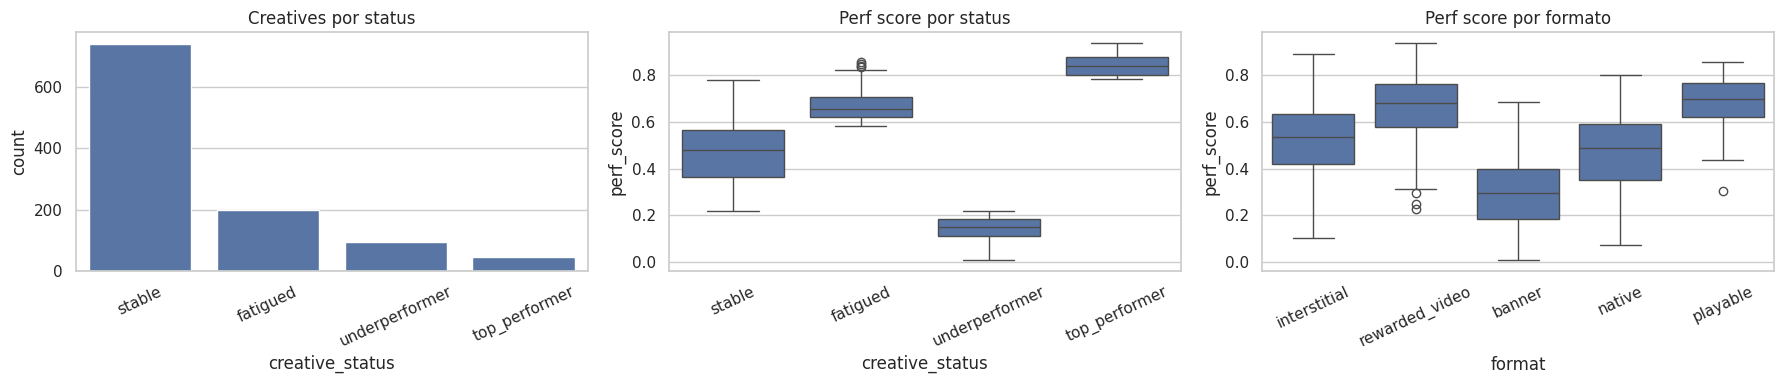

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

if HAS_SEABORN:
    sns.countplot(data=creative_summary, x="creative_status", order=status_counts["creative_status"], ax=axes[0])
    axes[0].tick_params(axis="x", rotation=25)
    sns.boxplot(data=creative_summary, x="creative_status", y="perf_score", order=status_counts["creative_status"], ax=axes[1])
    axes[1].tick_params(axis="x", rotation=25)
    sns.boxplot(data=creative_summary, x="format", y="perf_score", ax=axes[2])
    axes[2].tick_params(axis="x", rotation=25)
else:
    creative_summary["creative_status"].value_counts().plot(kind="bar", ax=axes[0])
    creative_summary.boxplot(column="perf_score", by="creative_status", ax=axes[1], rot=25)
    creative_summary.boxplot(column="perf_score", by="format", ax=axes[2], rot=25)

axes[0].set_title("Creatives por status")
axes[1].set_title("Perf score por status")
axes[2].set_title("Perf score por formato")
plt.tight_layout()
plt.show()

In [23]:
# Ranking robusto por categorías: media, mediana y volumen para evitar conclusiones por categorías pequeñas.
def category_performance(df, col, min_n=20):
    out = (
        df.groupby(col)
        .agg(
            creatives=("creative_id", "nunique"),
            median_perf_score=("perf_score", "median"),
            mean_perf_score=("perf_score", "mean"),
            median_roas=("overall_roas", "median"),
            median_ipm=("overall_ipm", "median"),
            top_performer_rate=("creative_status", lambda s: (s == "top_performer").mean()),
            fatigued_rate=("creative_status", lambda s: (s == "fatigued").mean()),
        )
        .query("creatives >= @min_n")
        .sort_values("median_perf_score", ascending=False)
    )
    return out.round(4)

for col in ["vertical", "format", "language", "theme", "hook_type", "cta_text", "dominant_color", "emotional_tone"]:
    print(f"\n{col}")
    display(category_performance(creative_summary, col, min_n=20).head(12))


vertical


,creatives,median_perf_score,mean_perf_score,median_roas,median_ipm,top_performer_rate,fatigued_rate
vertical,,,,,,,
gaming,180,0.6321,0.6246,1.3606,1.3540,0.0611,0.4500
travel,180,0.6269,0.6261,7.2668,0.3322,0.1611,0.2833
fintech,180,0.4877,0.4954,6.2010,0.3827,0.0167,0.0389
entertainment,180,0.4736,0.4586,1.9719,0.4420,0.0056,0.1389
food_delivery,180,0.4042,0.4002,1.8139,0.4209,0.0056,0.1389
ecommerce,180,0.4006,0.3978,2.2657,0.3041,0.0056,0.0556



format


,creatives,median_perf_score,mean_perf_score,median_roas,median_ipm,top_performer_rate,fatigued_rate
format,,,,,,,
playable,48,0.6978,0.6819,1.5143,1.7910,0.0625,0.5833
rewarded_video,200,0.6787,0.6595,2.2799,0.5768,0.1600,0.4350
interstitial,344,0.5326,0.5181,2.1709,0.4274,0.0174,0.1599
native,289,0.4889,0.4783,2.7642,0.3672,0.0173,0.0969
banner,199,0.2951,0.2987,2.0303,0.2853,0.0000,0.0050



language


...

,creatives,median_perf_score,mean_perf_score,median_roas,median_ipm,top_performer_rate,fatigued_rate
cta_text,,,,,,,
Shop now,122,0.5421,0.5236,2.3642,0.4183,0.0328,0.2459
Start now,97,0.5355,0.5143,2.3169,0.4361,0.0412,0.1959
Book now,100,0.5228,0.5073,2.4988,0.4041,0.0400,0.1900
Get offer,118,0.5213,0.4802,2.0104,0.4180,0.0424,0.2034
Order now,112,0.5142,0.4938,2.4668,0.3879,0.0446,0.1518
Try for free,117,0.5133,0.4999,2.3320,0.3998,0.0598,0.2222
Claim reward,107,0.5114,0.4947,2.1994,0.4203,0.0280,0.1308
Learn more,106,0.5011,0.5093,2.2478,0.4151,0.0377,0.1792
Watch now,92,0.4995,0.5005,2.6066,0.3933,0.0652,0.1522



dominant_color


,creatives,median_perf_score,mean_perf_score,median_roas,median_ipm,top_performer_rate,fatigued_rate
dominant_color,,,,,,,
orange,183,0.5485,0.5269,2.2819,0.4273,0.0546,0.2186
lime,143,0.5460,0.5168,1.9670,0.5257,0.0490,0.2098
blue,220,0.5373,0.5157,2.4181,0.4193,0.0500,0.1909
purple,190,0.5353,0.5126,2.0700,0.4410,0.0421,0.2316
red,76,0.4991,0.4830,2.1611,0.4240,0.0000,0.1711
white,66,0.4923,0.5003,5.7395,0.3445,0.0758,0.1212
teal,44,0.4628,0.5134,6.1250,0.3018,0.1136,0.2500
green,24,0.4468,0.4801,6.6889,0.3574,0.0000,0.1667
black,80,0.3850,0.4225,2.2201,0.3735,0.0000,0.0625



emotional_tone


,creatives,median_perf_score,mean_perf_score,median_roas,median_ipm,top_performer_rate,fatigued_rate
emotional_tone,,,,,,,
calm,172,0.5360,0.5186,2.4007,0.4318,0.0756,0.1744
excited,151,0.5336,0.5155,2.2725,0.4221,0.0265,0.2848
urgent,146,0.5099,0.5043,2.1768,0.4295,0.0685,0.1301
playful,149,0.5040,0.4874,2.2819,0.3854,0.0134,0.1879
adventurous,152,0.5003,0.5042,2.3367,0.4000,0.0526,0.1645
premium,153,0.4938,0.4969,2.2128,0.3932,0.0327,0.1765
trustworthy,157,0.4917,0.4749,2.5282,0.3917,0.0255,0.1720


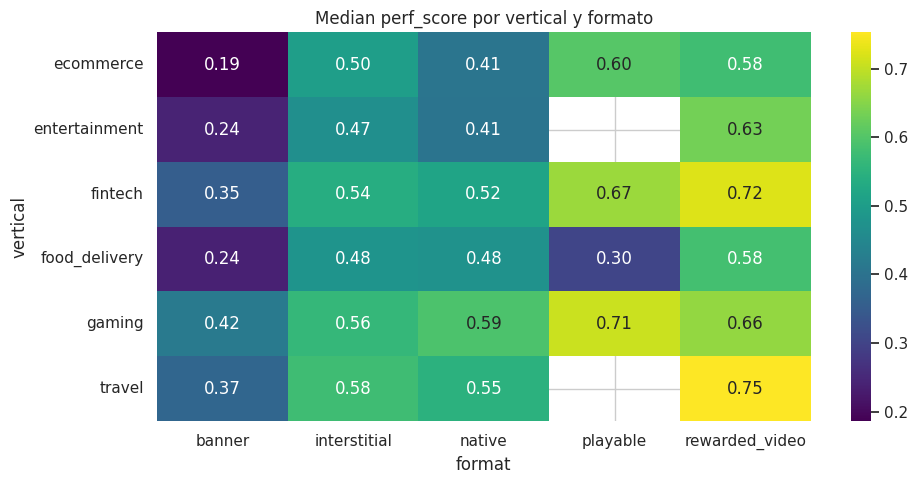

In [24]:
# Heatmap formato x vertical por perf_score mediano.
format_vertical = creative_summary.pivot_table(
    index="vertical", columns="format", values="perf_score", aggfunc="median"
)

plt.figure(figsize=(10, 5))
if HAS_SEABORN:
    sns.heatmap(format_vertical, annot=True, fmt=".2f", cmap="viridis")
else:
    plt.imshow(format_vertical, aspect="auto")
    plt.xticks(range(len(format_vertical.columns)), format_vertical.columns, rotation=30, ha="right")
    plt.yticks(range(len(format_vertical.index)), format_vertical.index)
    plt.colorbar(label="median perf_score")
plt.title("Median perf_score por vertical y formato")
plt.tight_layout()
plt.show()

## 11. Assets de imagen

Validamos que todos los PNG existen, que el `creative_id` está codificado en el filename y que las dimensiones reales coinciden con `width` / `height`. Esto habilita features visuales posteriores: colores reales, OCR, embedding visual, similitud, clustering.

In [25]:
from PIL import Image

asset_check = creatives[["creative_id", "asset_file", "width", "height", "format", "creative_launch_date"]].copy()
asset_check["asset_path"] = asset_check["asset_file"].map(lambda p: DATA_DIR / p)
asset_check["asset_exists"] = asset_check["asset_path"].map(lambda p: p.exists())
asset_check["creative_id_from_filename"] = asset_check["asset_file"].str.extract(r"creative_(\d+)\.png")[0].astype("Int64")
asset_check["filename_id_matches"] = asset_check["creative_id_from_filename"].eq(asset_check["creative_id"])

real_dims = []
for p in asset_check["asset_path"]:
    if p.exists():
        with Image.open(p) as img:
            real_dims.append((img.width, img.height))
    else:
        real_dims.append((np.nan, np.nan))
asset_check[["real_width", "real_height"]] = pd.DataFrame(real_dims, index=asset_check.index)
asset_check["dimensions_match"] = asset_check["width"].eq(asset_check["real_width"]) & asset_check["height"].eq(asset_check["real_height"])

asset_report = pd.DataFrame(
    [
        {"check": "asset file exists", "bad_rows": int((~asset_check["asset_exists"]).sum())},
        {"check": "creative_id matches filename", "bad_rows": int((~asset_check["filename_id_matches"]).sum())},
        {"check": "metadata dimensions match PNG", "bad_rows": int((~asset_check["dimensions_match"]).sum())},
        {"check": "duplicate asset_file", "bad_rows": int(asset_check["asset_file"].duplicated().sum())},
    ]
)
display(asset_report)
display(asset_check.groupby(["real_width", "real_height"]).size().rename("assets").reset_index().sort_values("assets", ascending=False))
display(asset_check.loc[~asset_check["asset_exists"] | ~asset_check["filename_id_matches"] | ~asset_check["dimensions_match"]].head(20))

,check,bad_rows
0,asset file exists,0
1,creative_id matches filename,0
2,metadata dimensions match PNG,0
3,duplicate asset_file,0


,real_width,real_height,assets
2,360,640,592
0,320,320,289
1,320,480,199


,creative_id,asset_file,width,height,format,creative_launch_date,asset_path,asset_exists,creative_id_from_filename,filename_id_matches,real_width,real_height,dimensions_match


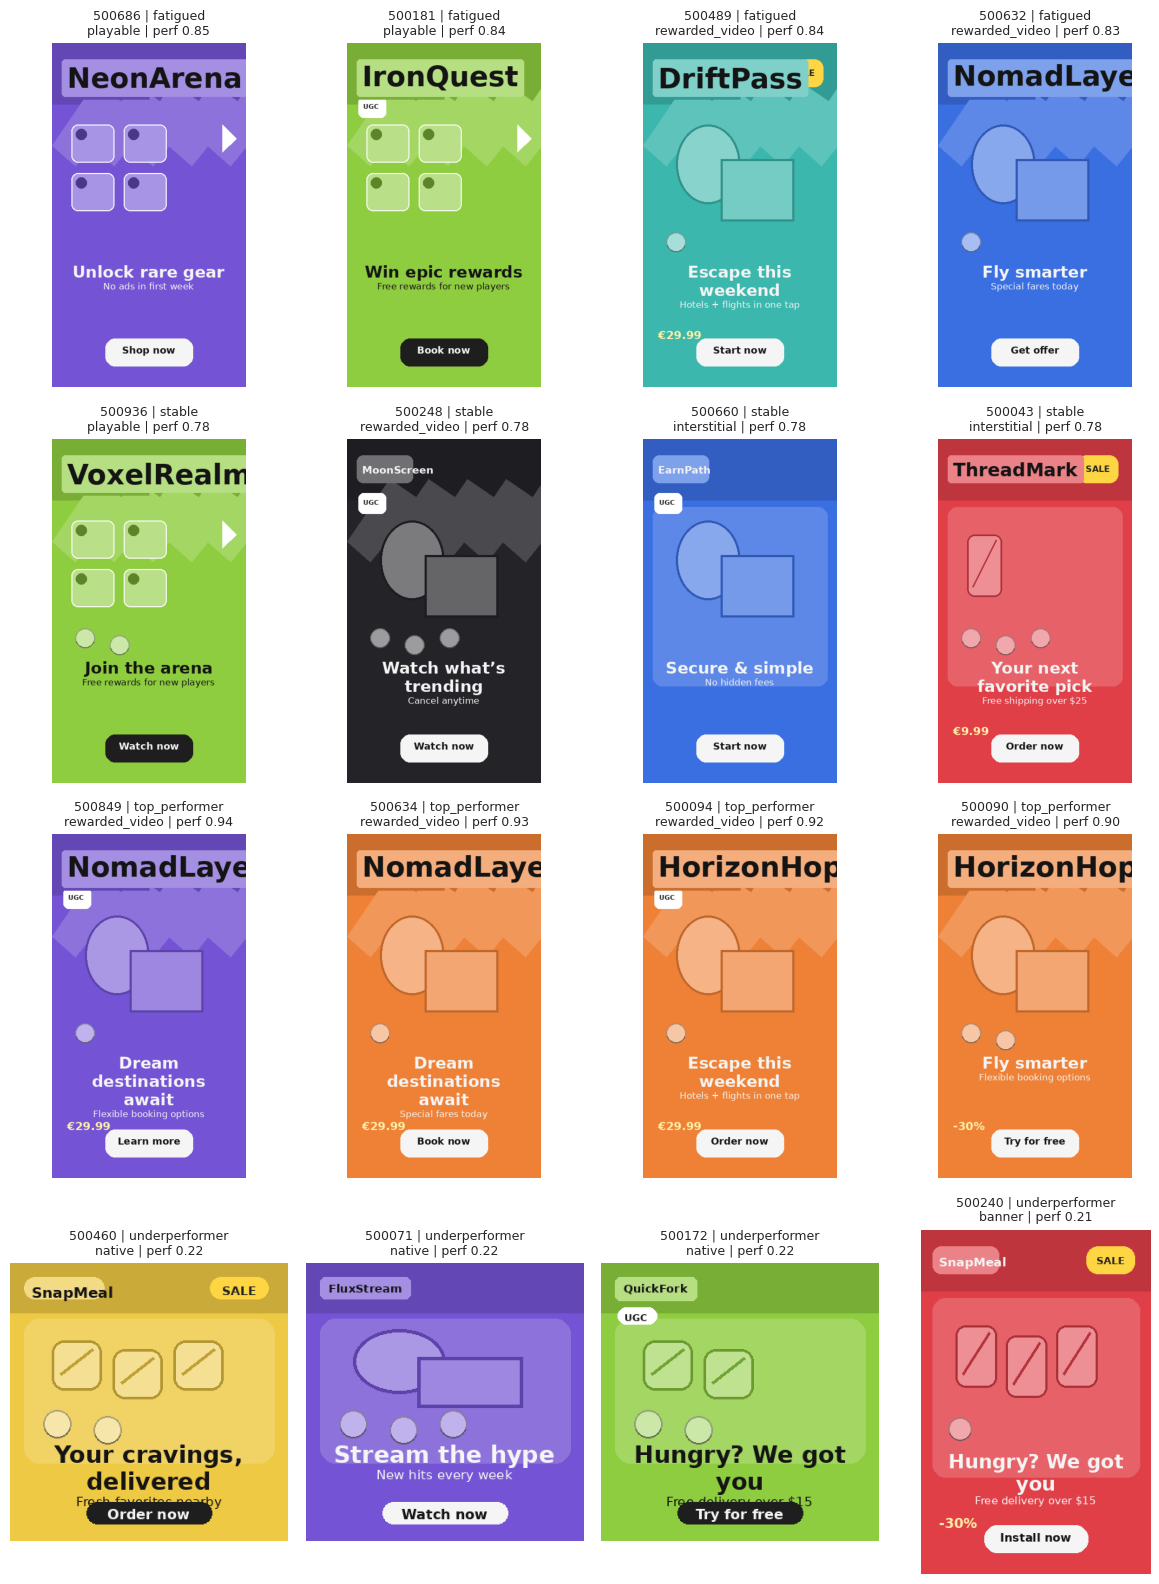

In [26]:
# Muestra visual estratificada por creative_status.
sample_assets = (
    creative_summary[["creative_id", "creative_status", "perf_score", "asset_file", "format", "vertical"]]
    .sort_values(["creative_status", "perf_score"], ascending=[True, False])
    .groupby("creative_status", group_keys=False)
    .head(4)
)

n = len(sample_assets)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 4))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, sample_assets.iterrows()):
    path = DATA_DIR / row["asset_file"]
    with Image.open(path) as img:
        ax.imshow(img)
    ax.set_title(f"{row['creative_id']} | {row['creative_status']}\n{row['format']} | perf {row['perf_score']:.2f}", fontsize=9)
    ax.axis("off")
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 12. Señal rápida de features estáticas

Entrenamos un modelo ligero solo con features estáticas de creative/campaign para ver qué variables parecen separar `creative_status`. Esto es EDA, no benchmark: sirve para priorizar feature engineering y detectar si la metadata por sí sola ya contiene señal.

                precision    recall  f1-score   support

      fatigued       0.40      0.66      0.50        50
        stable       0.84      0.70      0.77       185
 top_performer       0.50      0.27      0.35        11
underperformer       0.57      0.67      0.62        24

      accuracy                           0.67       270
     macro avg       0.58      0.58      0.56       270
  weighted avg       0.72      0.67      0.69       270



,feature,importance
16,num__daily_budget_usd,0.074853
23,cat__format_banner,0.062389
2,num__duration_sec,0.056081
27,cat__format_rewarded_video,0.050421
1,num__height,0.047385
9,num__motion_score,0.045415
8,num__novelty_score,0.039210
0,num__width,0.037292
7,num__clutter_score,0.037138
22,cat__vertical_travel,0.033525


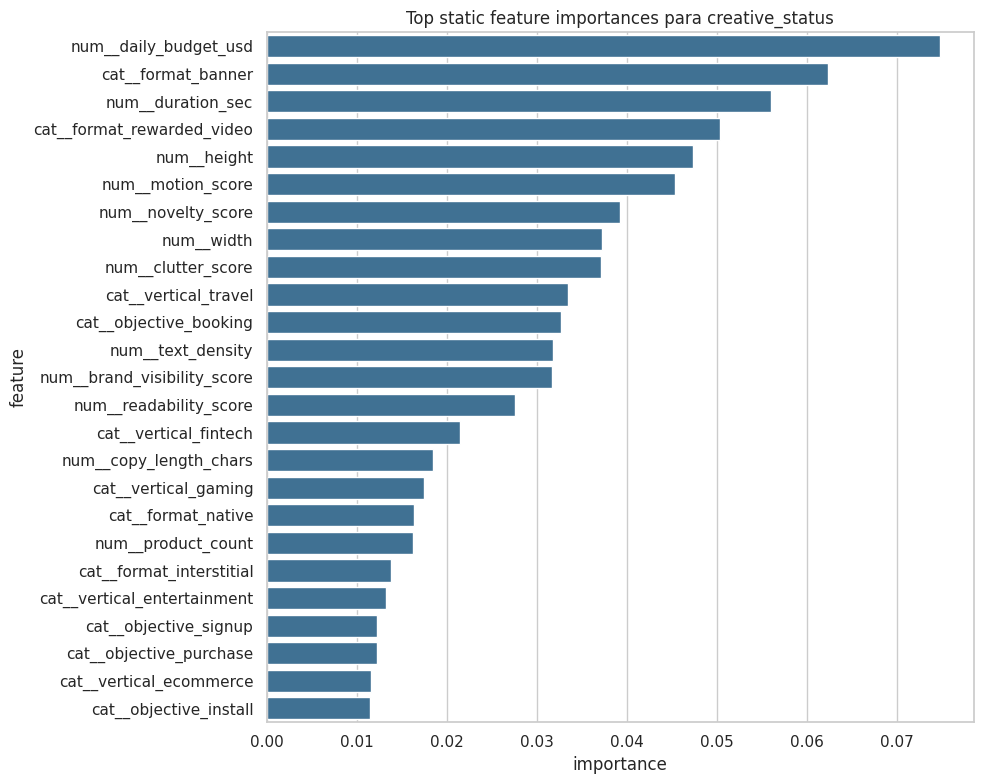

In [27]:
try:
    from sklearn.compose import ColumnTransformer
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import classification_report
    from sklearn.model_selection import train_test_split
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder

    static_feature_cols = [
        "vertical", "format", "width", "height", "language", "theme", "hook_type", "cta_text",
        "dominant_color", "emotional_tone", "duration_sec", "text_density", "copy_length_chars",
        "readability_score", "brand_visibility_score", "clutter_score", "novelty_score", "motion_score",
        "faces_count", "product_count", "has_price", "has_discount_badge", "has_gameplay", "has_ugc_style",
        "objective", "primary_theme", "target_age_segment", "target_os", "daily_budget_usd", "kpi_goal", "hq_region",
    ]
    model_df = creative_feature_base[static_feature_cols + ["creative_status"]].dropna(subset=["creative_status"]).copy()
    y = model_df["creative_status"]
    X = model_df[static_feature_cols]

    numeric_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), numeric_cols),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
        ]
    )
    clf = Pipeline(
        [
            ("prep", preprocessor),
            ("rf", RandomForestClassifier(n_estimators=350, min_samples_leaf=8, random_state=42, class_weight="balanced_subsample")),
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    print(classification_report(y_test, preds))

    feature_names = clf.named_steps["prep"].get_feature_names_out()
    importances = clf.named_steps["rf"].feature_importances_
    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(40)
    )
    display(importance_df)

    plt.figure(figsize=(10, 8))
    if HAS_SEABORN:
        sns.barplot(data=importance_df.head(25), y="feature", x="importance", color="#3274a1")
    else:
        plt.barh(importance_df.head(25)["feature"], importance_df.head(25)["importance"])
        plt.gca().invert_yaxis()
    plt.title("Top static feature importances para creative_status")
    plt.tight_layout()
    plt.show()
except ImportError as exc:
    print("sklearn no está instalado. Para ejecutar esta sección: pip install scikit-learn")
    print(exc)

## 13. Checklist final antes de modelar

- Para análisis descriptivo global, `creative_summary` es cómodo y está validado contra `daily`.
- Para modelos o recomendaciones temporales, calcula features desde `daily` con una fecha de corte; no uses totales de `creative_summary` como predictores.
- Recalcula ventanas calendario desde `creative_day`; evita `impressions_last_7d` porque es rolling de 7 filas, no de 7 días.
- Usa `merge(..., validate=...)` siempre: `m:1` para fact/dim y `1:1` para summary/base.
- Si explotas `campaigns.countries`, une con `campaign_id + country`; nunca con `country` a secas.
- Mantén `creative_id` como clave de asset y `asset_file` como path, no como clave semántica.

In [28]:
# Objetos principales que quedan listos en memoria:
ready_objects = pd.DataFrame(
    [
        {"object": "campaign_dim", "grain": "1 row per campaign_id", "shape": campaign_dim.shape, "use": "contexto de campaña sin duplicados innecesarios"},
        {"object": "creative_dim", "grain": "1 row per creative_id", "shape": creative_dim.shape, "use": "metadata creativa + contexto campaña/anunciante"},
        {"object": "creative_day", "grain": "1 row per creative_id-date", "shape": creative_day.shape, "use": "features temporales limpias"},
        {"object": "daily_enriched", "grain": "1 row per date-creative-country-os", "shape": daily_enriched.shape, "use": "fact table enriquecida para cortes por país/OS"},
        {"object": "creative_feature_base", "grain": "1 row per creative_id", "shape": creative_feature_base.shape, "use": "starter dataset para feature engineering"},
    ]
)
display(ready_objects)

,object,grain,shape,use
0,campaign_dim,1 row per campaign_id,"(180, 12)",contexto de campaña sin duplicados innecesarios
1,creative_dim,1 row per creative_id,"(1080, 43)",metadata creativa + contexto campaña/anunciante
2,creative_day,1 row per creative_id-date,"(52349, 32)",features temporales limpias
3,daily_enriched,1 row per date-creative-country-os,"(192315, 55)",fact table enriquecida para cortes por país/OS
4,creative_feature_base,1 row per creative_id,"(1080, 111)",starter dataset para feature engineering
